In [20]:
print("hello")

hello


In [3]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt


# Predicting Freight Cost

## Objective
Predict freight cost for a vendor invoice using **quantity** and **dollar amount** to improve **cost forecasting**, **budgeting**, and **vendor negotiation**.

- Freight is a significant component of landed cost.  
- Inaccurate freight estimates can distort profit margins and inventory planning.  
- Automating freight estimation allows procurement teams to forecast true costs **before invoice arrival**.

In [4]:

conn = sqlite3.connect(r"C:\Users\Hp\Desktop\Vendor_Invoice_Intelligence_System\data\inventory.db")
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)


In [5]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [10]:
for table in tables['name']:
    print("Table name", table)

Table name purchases
Table name purchase_prices
Table name vendor_invoice
Table name begin_inventory
Table name end_inventory


In [9]:
for table in tables['name']:
    print("Table name", table)
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [11]:
vendor_df = pd.read_sql_query("select * from vendor_invoice", conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [14]:
vendor_df[['Quantity','Freight','Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


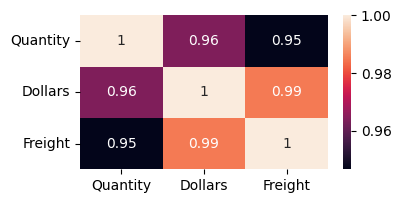

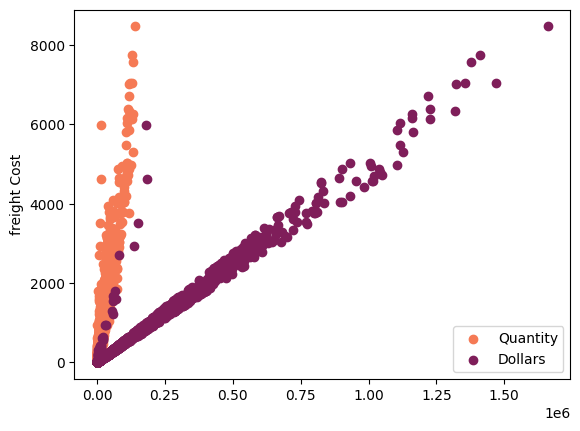

In [24]:
# Relationship between Quantity, Dollars and Freght

plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity','Dollars','Freight']].corr(), annot=True)
plt.show()



plt.scatter(vendor_df['Quantity'], vendor_df['Freight'], color='#f57a55')
plt.scatter(vendor_df['Dollars'], vendor_df['Freight'], color='#7f1e5a')
plt.legend(['Quantity','Dollars'])
plt.ylabel('freight Cost')
plt.show()

In [25]:
vendor_df['freight_per_unit'] = vendor_df['Freight'] / vendor_df['Quantity']

In [26]:
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809


In [29]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)


In [31]:
low_quantity

np.float64(83.0)

In [32]:
high_quantity

np.float64(5100.5)

In [39]:
vendor_df.loc[vendor_df['Quantity'] < low_quantity].freight_per_unit.mean()

np.float64(0.09489854253138316)

In [40]:
vendor_df.loc[vendor_df['Quantity'] > high_quantity].freight_per_unit.mean()

np.float64(0.049077654690759046)

In [49]:
# Q1 = vendor_df['Quantity'].quantile(0.25)
# Q3 = vendor_df['Quantity'].quantile(0.75)
# IQR = Q3 - Q1

# # Outlier condition
# outliers = vendor_df[(vendor_df['Quantity'] < Q1 - 1.5*IQR) | (vendor_df['Quantity'] > Q3 + 1.5*IQR)]
# print(outliers)

In [108]:
X = vendor_df[['Dollars']]
y = vendor_df['Freight']

In [109]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [110]:
from sklearn.model_selection import train_test_split

In [111]:
x_train, x_test , y_train, y_test = train_test_split(X,y , test_size = 0.2, random_state = 42)

In [112]:
x_train

,Dollars
2609,264.24
5527,342.48
5321,572.40
3805,68821.14
1215,604197.73
...,...
3772,2618.27
5191,74386.98
5226,36.96
5390,644.00


In [113]:
x_test

,Dollars
4564,352.95
1616,225706.96
4861,634.11
230,987.34
2042,31768.74
...,...
3388,242.16
1321,846.99
1322,205379.19
3618,242967.77


In [114]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score


In [115]:
model1 = LinearRegression()
model1.fit(x_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [116]:

model2 = DecisionTreeRegressor(max_depth = 4, random_state=42)
model2.fit(x_train, y_train)




,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [117]:
model3 = RandomForestRegressor(random_state=42)
model3.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [118]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, x_test, y_test, model_name):
    preds = model.predict(x_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))  # <-- এখানে square root
    r2 = r2_score(y_test, preds) * 100

    print(f"\n{model_name}, Performance: ")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"Rsquer : {r2:.2f}%")

In [119]:
evaluate_model(model1, x_test,y_test,'Linear Regression')
evaluate_model(model2, x_test,y_test,'Decision Tree Regressor')
evaluate_model(model3, x_test,y_test,'Random Forest Regressor')


Linear Regression, Performance: 
MAE : 24.11
RMSE : 124.72
Rsquer : 96.99%

Decision Tree Regressor, Performance: 
MAE : 38.12
RMSE : 138.25
Rsquer : 96.30%

Random Forest Regressor, Performance: 
MAE : 28.27
RMSE : 142.21
Rsquer : 96.08%


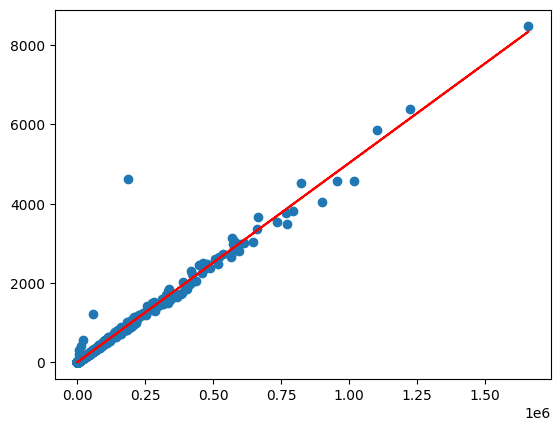

In [121]:
plt.scatter(x_test,y_test)
plt.plot(x_test, model1.predict(x_test), color='red')

In [122]:
input_data = {
    "Dollars" : [18500, 9000],
}

df = pd.DataFrame(input_data)

In [123]:
model1.predict(df)

array([97.78868161, 50.14455838])